<a href="https://colab.research.google.com/github/ggg2929/MagiskOnWSALocal/blob/main/Data_Tik_Tok.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Normalisasi

In [2]:
# ===================== 🔧 INSTALASI LIBRARY =====================
!pip install -q fasttext Sastrawi pandas tqdm

# ===================== 📦 DOWNLOAD fastText Bahasa Indonesia =====================
!wget -q https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.id.300.bin.gz
!gzip -d cc.id.300.bin.gz  # Hasil = cc.id.300.bin

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 1.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 6.4 MB/s eta 0:00:00


In [1]:
# ===================== 🔧 INSTALL (jalankan jika perlu) =====================
# !pip install fasttext pandas tqdm

# ===================== 📚 IMPORT LIBRARY =====================
import pandas as pd
import re
import fasttext
from tqdm import tqdm

# ===================== 📦 LOAD MODEL fastText =====================
print("📦 Memuat model fastText Bahasa Indonesia...")
ft_model = fasttext.load_model("cc.id.300.bin")  # Pastikan file ini tersedia

# ===================== 📁 BACA DATA KOMENTAR =====================
print("📁 Membaca file komentar...")
df = pd.read_csv("Data3.csv")  # Ganti jika nama file beda
df['text'] = df['text'].astype(str)

# ===================== 📌 FRASA PENTING (mapping sebelum proses per kata) =====================
frasa_khusus = {
    "ra mudeng": "tidak paham",
    "ora mudeng": "tidak paham",
    "ora ngerti": "tidak paham",
    "gak ngerti": "tidak paham",
    "nggak ngerti": "tidak paham",
    "gak mudeng": "tidak paham",
    "tidak ngerti": "tidak paham",
    "ngerti": "paham",
    "ngeh": "paham",
    "mudeng": "paham"
}

# ===================== 💡 CACHING UNTUK KATA UNIK =====================
cache_kata = {}

def normalisasi_otomatis_aman(word, threshold=0.75):
    word = word.lower()
    if word in cache_kata:
        return cache_kata[word]

    try:
        tetangga = ft_model.get_nearest_neighbors(word)
        for sim, near_word in tetangga:
            if sim >= threshold and near_word != word:
                cache_kata[word] = near_word
                return near_word
    except:
        pass
    cache_kata[word] = word
    return word

# ===================== 🔁 PRE-PROSES: BUAT KAMUS DARI SEMUA KATA UNIK =====================
print("🔍 Mengumpulkan semua kata unik...")
kata_unik = set()
for teks in df['text']:
    teks_bersih = teks.lower()
    for frasa, ganti in frasa_khusus.items():
        teks_bersih = teks_bersih.replace(frasa, ganti)
    tokens = re.sub(r'[^\w\s]', '', teks_bersih).split()
    kata_unik.update(tokens)

print(f"📊 Ditemukan {len(kata_unik)} kata unik. Memproses normalisasi dengan fastText...")

# Buat kamus normalisasi dari semua kata unik
normalisasi_dict = {}
for kata in tqdm(kata_unik, desc="⚙️ Normalisasi kata unik"):
    normalisasi_dict[kata] = normalisasi_otomatis_aman(kata)

# ===================== 🔁 PROSES NORMALISASI KOMENTAR MENGGUNAKAN KAMUS =====================
def normalisasi_kalimat_cepat(kalimat):
    kalimat = kalimat.lower()
    for frasa, ganti in frasa_khusus.items():
        kalimat = kalimat.replace(frasa, ganti)
    tokens = re.sub(r'[^\w\s]', '', kalimat).split()
    return ' '.join([normalisasi_dict.get(tok, tok) for tok in tokens])

print("🚀 Memulai proses normalisasi komentar...")
tqdm.pandas(desc="🔄 Normalisasi komentar")
df['komentar_normal'] = df['text'].progress_apply(normalisasi_kalimat_cepat)

# ===================== 💾 SIMPAN HASIL =====================
df.to_csv("normalisasiTiktok.csv", index=False)
print("✅ Proses selesai! Hasil disimpan sebagai 'normalisasiTikTok.csv'")


📦 Memuat model fastText Bahasa Indonesia...
📁 Membaca file komentar...
🔍 Mengumpulkan semua kata unik...
📊 Ditemukan 7261 kata unik. Memproses normalisasi dengan fastText...


⚙️ Normalisasi kata unik: 100%|██████████| 7261/7261 [2:03:09<00:00,  1.02s/it]


🚀 Memulai proses normalisasi komentar...


🔄 Normalisasi komentar: 100%|██████████| 4379/4379 [00:00<00:00, 121708.97it/s]

✅ Proses selesai! Hasil disimpan sebagai 'normalisasiTikTok.csv'


**lihat hasil normalisasi**

In [2]:
import pandas as pd
from tabulate import tabulate

# Baca hasil CSV
df = pd.read_csv("normalisasiTiktok.csv")

# Tampilkan 20 kata paling sering dalam tabel rapi
print(tabulate(df.head(20), headers='keys', tablefmt='fancy_grid'))


╒════╤══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╤═════════════════════╤══════════════╤══════════════════════════╤═════════════╤════════════════════════════════════════════════════════════════════╤═════════════════╤══════════════════╤═══════════════╤═════════════════════╤════════════════════════════════════════════════════════════════════╤═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╤═════════════════════╤════════════════╤════════════════════════════════════════════════════════════════════╤════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════

***Preprocessing***

In [3]:
!pip install sastrawi
!pip install nltk

In [5]:
# ===================== 🔧 INSTALASI =====================
# !pip install -q Sastrawi nltk

# ===================== 📚 IMPORT =====================
import pandas as pd
import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

# ===================== 🔧 SETUP STEMMER =====================
stemmer = StemmerFactory().create_stemmer()

# ===================== 📁 LOAD DATA NORMALISASI =====================
df = pd.read_csv("normalisasiTiktok.csv")  # dari langkah sebelumnya
df['komentar_normal'] = df['komentar_normal'].astype(str)

# ===================== 🧹 FUNGSI PREPROCESS NLP =====================
def preprocess_nlp(teks):
    teks = teks.lower()  # lower
    teks = re.sub(r'[^\w\s]', '', teks)  # hapus tanda baca
    tokens = word_tokenize(teks)  # tokenisasi
    tokens = [stemmer.stem(token) for token in tokens]  # stemming
    hasil = ' '.join(tokens)
    return hasil

# ===================== 🔁 TERAPKAN KE SEMUA KOMENTAR =====================
df['komentar_nlp'] = df['komentar_normal'].apply(preprocess_nlp)

# ===================== 🧼 HAPUS NaN JIKA ADA =====================
df.dropna(subset=['komentar_normal', 'komentar_nlp'], inplace=True)

# ===================== 💾 SIMPAN HASIL =====================
df.to_csv("preprocessTiktok", index=False)
print("✅ File 'preprocessTiktok.csv' berhasil disimpan.")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


✅ File 'preprocessTiktok.csv' berhasil disimpan.


***alat deteksi konsentrasi***

In [7]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output

# Load file komentar yang sudah dipreprocessing (ganti path jika perlu)
df = pd.read_csv("preprocessTiktok")
df = df[df['komentar_nlp'].notna()].copy()
df['label_manual'] = None

# Setup
index = 0
output = widgets.Output()

# Tombol
btn_konsen = widgets.Button(description="✅ Konsentrasi", button_style='success')
btn_tdk_konsen = widgets.Button(description="❌ Tidak Konsentrasi", button_style='danger')
btn_skip = widgets.Button(description="⏭️ Lewati", button_style='warning')
btn_finish = widgets.Button(description="🛑 Selesai Sekarang", button_style='info')

# Tampilkan komentar ke layar
def show_comment():
    with output:
        clear_output(wait=True)
        print(f"Komentar {index+1}/{len(df)}:")
        print("\n", df.iloc[index]['komentar_nlp'])

# Fungsi aksi tombol
def on_konsen_clicked(b):
    global index
    df.at[df.index[index], 'label_manual'] = 1
    index += 1
    if index < len(df):
        show_comment()
    else:
        save_and_finish()

def on_tdk_konsen_clicked(b):
    global index
    df.at[df.index[index], 'label_manual'] = 0
    index += 1
    if index < len(df):
        show_comment()
    else:
        save_and_finish()


def on_skip_clicked(b):
    global index
    index += 1
    if index < len(df):
        show_comment()
    else:
        save_and_finish()

# Tombol selesai manual
def on_finish_clicked(b):
    save_and_finish()

# Simpan ke CSV setelah selesai
def save_and_finish():
    path = "preprocessTiktok_labeled_manual.csv"
    df.to_csv(path, index=False)
    with output:
        clear_output()
        print(f"✅ Selesai! Data disimpan di: {path}")

# Hubungkan tombol ke fungsi
tn = [
    (btn_konsen, on_konsen_clicked),
    (btn_tdk_konsen, on_tdk_konsen_clicked),
    (btn_skip, on_skip_clicked),
    (btn_finish, on_finish_clicked)
]
for btn, func in tn:
    btn.on_click(func)

# Tampilkan awal
show_comment()
display(widgets.HBox([btn_konsen, btn_tdk_konsen, btn_skip, btn_finish]))
display(output)


Output()

***Labeling***

In [8]:
!pip install qgrid
!pip install itables

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 889.2/889.2 kB 9.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 38.6 MB/s eta 0:00:00
  Created wheel for qgrid: filename=qgrid-1.3.1-py2.py3-none-any.whl size=1761252 sha256=ff271e12d9c3baf460593fca94401cf15ff27cdcea3e79bcef9d13d79e926c7f
  Stored in directory: /root/.cache/pip/wheels/7f/0f/d6/33b60aa35dbdc3d3e84c44b780c85e92d8767b698843f9e256
Successfully built qgrid
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 15.7 MB/s eta 0:00:00


In [9]:
# ===========================
# 🔍 TRAINING MODEL DARI 8 LABELING MANUAL + PREDIKSI SEMUA DATA
# ===========================
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
import joblib

# 1. Load semua data
df_all = pd.read_csv("preprocessTiktok_labeled_manual.csv")

# 2. Pisahkan data berlabel (label_manual tidak kosong) → hanya 8 data ini untuk training
df_train = df_all.dropna(subset=['komentar_nlp', 'label_manual']).copy()
df_train['label_manual'] = df_train['label_manual'].astype(int)

# 3. Pisahkan komentar NLP dari semua data (termasuk yang tidak dilabeli)
all_komentar = df_all['komentar_nlp']

# 4. Vectorisasi TF-IDF berdasarkan data training
vectorizer = TfidfVectorizer(max_features=3000)
X_train_tfidf = vectorizer.fit_transform(df_train['komentar_nlp'])
y_train = df_train['label_manual']

# 5. Train model dari 8 data manual
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# 6. Simpan model & vectorizer
joblib.dump(model, "model_konsentrasi.pkl")
joblib.dump(vectorizer, "vectorizer_konsentrasi.pkl")
print("\n✅ Model dan vectorizer berhasil disimpan!")

# 7. Prediksi semua komentar dari seluruh dataset
all_tfidf = vectorizer.transform(all_komentar)
df_all['prediksi_konsentrasi'] = model.predict(all_tfidf)
df_all['kategori'] = df_all['prediksi_konsentrasi'].map({1: 'Konsentrasi', 0: 'Tidak Konsentrasi'})

# 8. Simpan hasil lengkap
df_all.to_csv("preprocessTiktok.csv", index=False)
print("\n📁 File dengan prediksi disimpan di: preprocessTiktok.csv")

# 9. Tampilkan semua data
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
display(df_all[['komentar_normal', 'komentar_nlp', 'kategori']])


✅ Model dan vectorizer berhasil disimpan!

📁 File dengan prediksi disimpan di: preprocessTiktok.csv


,komentar_normal,komentar_nlp,kategori
0,power. bi ez jg sulit nge power. bi Di Macbook,power bi ez jg sulit nge power bi di macbook,Tidak Konsentrasi
1,saran bang mulai dari dimana Saya udah-udah pusingnya burnout sama sofware engineer.,saran bang mulai dari mana saya udahudah pusing burnout sama sofware engineer,Tidak Konsentrasi
2,orang-orang jg udah-udah memiliki basic-basic data-data analisa sama data-data science. keluar kuliahnya Si senyuman senyuman liat big data-data,orangorang jg udahudah milik basicbasic datadata analisa sama datadata science keluar kuliah si senyum senyum liat big datadata,Konsentrasi
3,Datawarehouse donkk,datawarehouse donkk,Konsentrasi
4,anak-anak industriindustri juga balajar tersebut,anakanak industriindustri juga balajar sebut,Konsentrasi
5,yag atu ngapain tersebut mas,yag atu ngapain sebut mas,Tidak Konsentrasi
6,buat bikin-bikin dashboar kek giniii bagusnya pakek power. bi ataupun table3 Ya ka,buat bikinbikin dashboar kek giniii bagus pakek power bi atau table3 ya ka,Konsentrasi
7,bikin2 Di app apa bang,bikin2 di app apa bang,Tidak Konsentrasi
8,bang sebenernya realistik orang-orang yag awam dapat switch karier ke data-data makasi bang klo nantinya dijawabnya,bang sebenernya realistik orangorang yag awam dapat switch karier ke datadata makas bang klo nanti jawab,Tidak Konsentrasi
9,Aku pumya kpi pingin Aku buat dashboar cuman Aku nggak tahu data-data b ditampilkan bentuknya padata c didalam diagram-diagram apa wkwkkwkwk,aku pumya kpi pingin aku buat dashboar cuman aku nggak tahu datadata b tampil bentuk padata c dalam diagramdiagram apa wkwkkwkwk,Tidak Konsentrasi


=== Jumlah Data per Kategori ===
kategori
Konsentrasi          3207
Tidak Konsentrasi     490
Name: count, dtype: int64


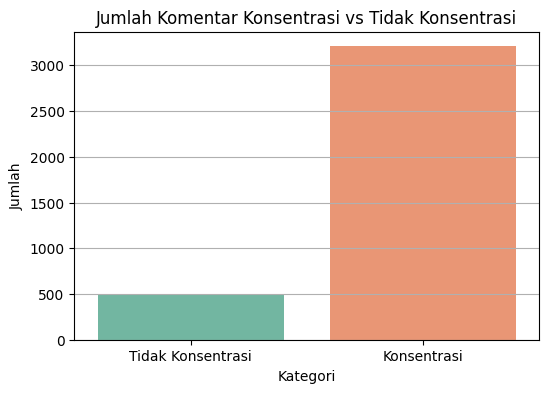


=== Kata Teratas - Konsentrasi ===


,Kata,Frekuensi
0,sebut,415
1,kak,400
2,di,394
3,jg,254
4,datadata,242
5,nya,238
6,ya,224
7,aku,202
8,serta,201
9,ada,192



=== Kata Teratas - Tidak Konsentrasi ===


,Kata,Frekuensi
0,bang,146
1,yag,96
2,apa,63
3,sama,51
4,sebut,46
5,sangat,42
6,klo,36
7,ada,32
8,dari,28
9,saya,28


<ipython-input-10-3481208622>:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_konsentrasi, y='Kata', x='Frekuensi', palette='Blues_r')
<ipython-input-10-3481208622>:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_tdk_konsentrasi, y='Kata', x='Frekuensi', palette='Oranges_r')
<ipython-input-10-3481208622>:60: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-10-3481208622>:60: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) 

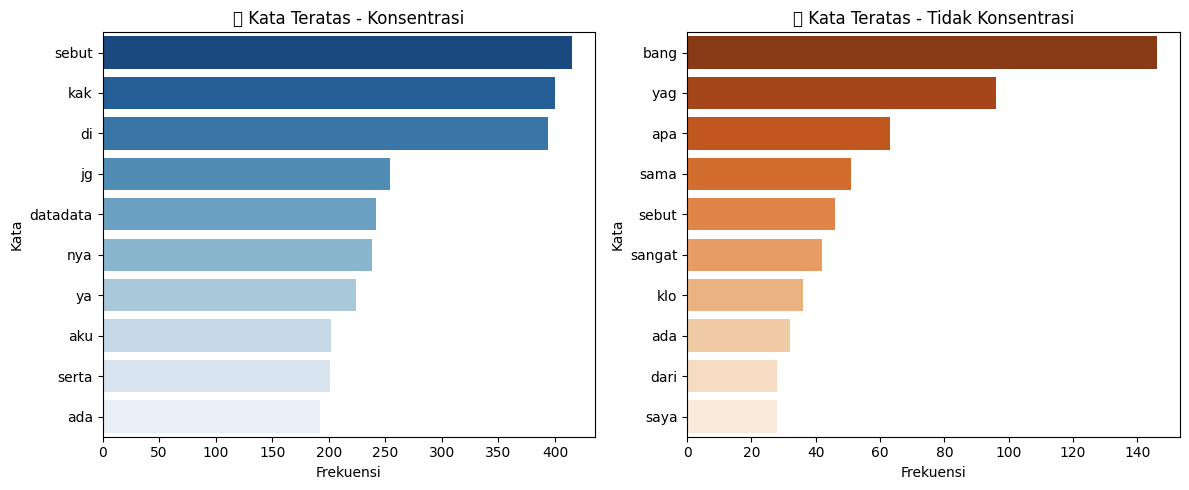

In [10]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Hitung jumlah kategori
jumlah_kategori = df_all['kategori'].value_counts()
print("=== Jumlah Data per Kategori ===")
print(jumlah_kategori)

# 2. Tampilkan diagram jumlah kategori
plt.figure(figsize=(6,4))
sns.countplot(data=df_all, x='kategori', palette='Set2')
plt.title("Jumlah Komentar Konsentrasi vs Tidak Konsentrasi")
plt.xlabel("Kategori")
plt.ylabel("Jumlah")
plt.grid(axis='y')
plt.show()

# 3. Tokenisasi komentar_nlp → pisahkan per kategori
df_all['tokens'] = df_all['komentar_nlp'].astype(str).str.split()

# Ambil token per kategori
tokens_konsentrasi = df_all[df_all['kategori'] == 'Konsentrasi']['tokens'].sum()
tokens_tdk_konsentrasi = df_all[df_all['kategori'] == 'Tidak Konsentrasi']['tokens'].sum()

# Hitung kata paling sering muncul
# Check if the token list is not empty before using Counter
top_konsentrasi = Counter(tokens_konsentrasi).most_common(10) if tokens_konsentrasi else []
top_tdk_konsentrasi = Counter(tokens_tdk_konsentrasi).most_common(10) if tokens_tdk_konsentrasi else []

# Buat dataframe
df_konsentrasi = pd.DataFrame(top_konsentrasi, columns=['Kata', 'Frekuensi'])
df_tdk_konsentrasi = pd.DataFrame(top_tdk_konsentrasi, columns=['Kata', 'Frekuensi'])

# 4. Tampilkan tabel
print("\n=== Kata Teratas - Konsentrasi ===")
display(df_konsentrasi)

print("\n=== Kata Teratas - Tidak Konsentrasi ===")
display(df_tdk_konsentrasi)

# 5. Diagram kata teratas
plt.figure(figsize=(12, 5))

# Konsentrasi
plt.subplot(1, 2, 1)
sns.barplot(data=df_konsentrasi, y='Kata', x='Frekuensi', palette='Blues_r')
plt.title("🔵 Kata Teratas - Konsentrasi")
plt.xlabel("Frekuensi")
plt.ylabel("Kata")

# Tidak Konsentrasi
plt.subplot(1, 2, 2)
sns.barplot(data=df_tdk_konsentrasi, y='Kata', x='Frekuensi', palette='Oranges_r')
plt.title("🟠 Kata Teratas - Tidak Konsentrasi")
plt.xlabel("Frekuensi")
plt.ylabel("Kata")

plt.tight_layout()
plt.show()

***Pelatihan Model***

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 15s 126ms/step - accuracy: 0.8465 - loss: 0.4599 - val_accuracy: 0.8716 - val_loss: 0.3733
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 18s 104ms/step - accuracy: 0.8685 - loss: 0.3474 - val_accuracy: 0.8919 - val_loss: 0.2604
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - accuracy: 0.9536 - loss: 0.1149 - val_accuracy: 0.9189 - val_loss: 0.2239
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - accuracy: 0.9926 - loss: 0.0297 - val_accuracy: 0.9189 - val_loss: 0.2974
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 11s 113ms/step - accuracy: 0.9972 - loss: 0.0142 - val_accuracy: 0.9088 - val_loss: 0.3081
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - accuracy: 0.9993 - loss: 0.0100 - val_accuracy: 0.9122 - val_loss: 0.3455
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 9s 104ms/step - accuracy: 1.0000 - loss: 0.0049 - val_accuracy: 0.9122 - val_loss: 0.3787
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - accuracy: 0.9996 - loss: 0.0032 - val_accuracy: 

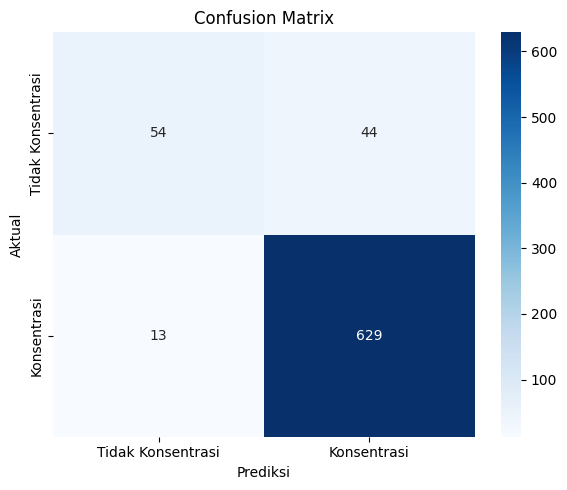

In [11]:
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load data
df = pd.read_csv('preprocessTiktok.csv')
df = df.dropna(subset=['text', 'prediksi_konsentrasi'])

# 2. Label dan data teks
texts = df['text'].values
labels = df['prediksi_konsentrasi'].values

# 3. Tokenisasi teks
max_words = 10000  # jumlah maximal kata
max_len = 100      # panjang sequence (bisa disesuaikan)

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
X = pad_sequences(sequences, maxlen=max_len)

# 4. Label untuk binary classification (0 dan 1)
y = labels

# 5. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Bangun model CNN
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
model.add(Conv1D(filters=128, kernel_size=5, activation='relu'))
model.add(GlobalMaxPooling1D())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))  # output 1 node dengan sigmoid untuk binary classification

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

# 7. Latih model
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    class_weight={0: 1, 1: 1}  # Bisa diatur sesuai kebutuhan
)

# 8. Evaluasi
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print("\n=== Classification Report ===")

unique_labels_test = np.unique(y_test)

if len(unique_labels_test) < 2:
    print("Note: Only one class is present in the test set due to limited training data. Classification report is not applicable.")
    # Manually calculate and print accuracy if only one class is present
    print(f"✅ Akurasi: {accuracy_score(y_test, y_pred) * 100:.2f} %")
else:
    target_names = ['Tidak Konsentrasi', 'Konsentrasi']
    # Filter target_names based on unique labels in y_test
    filtered_target_names = [name for i, name in enumerate(target_names) if i in unique_labels_test]
    print(classification_report(y_test, y_pred, target_names=filtered_target_names))
    print("\n✅ Akurasi:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")

# Ensure confusion matrix labels match the unique labels in y_test
cm = confusion_matrix(y_test, y_pred, labels=unique_labels_test)
labels_cm = [name for i, name in enumerate(['Tidak Konsentrasi', 'Konsentrasi']) if i in unique_labels_test]


plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_cm, yticklabels=labels_cm)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

***Kesimpulan***

In [12]:
# === Analisis Konsentrasi Otomatis ===
total_konsentrasi = jumlah_kategori.get('Konsentrasi', 0)
total_tidak_konsentrasi = jumlah_kategori.get('Tidak Konsentrasi', 0)
total_data = total_konsentrasi + total_tidak_konsentrasi

persen_konsentrasi = (total_konsentrasi / total_data) * 100 if total_data else 0
persen_tidak = (total_tidak_konsentrasi / total_data) * 100 if total_data else 0

print(f"\n📊 Total Data: {total_data}")
print(f"✅ Konsentrasi: {total_konsentrasi} data ({persen_konsentrasi:.2f}%)")
print(f"❌ Tidak Konsentrasi: {total_tidak_konsentrasi} data ({persen_tidak:.2f}%)")
print("\n--- KESIMPULAN ---")

if persen_konsentrasi > 80:
    print("✅ Mayoritas mahasiswa menunjukkan konsentrasi saat belajar pemrograman melalui media Instagram.")
    print("💡 Hal ini menunjukkan bahwa media Instagram efektif dan menunjang dalam meningkatkan konsentrasi belajar mahasiswa.")
elif persen_konsentrasi > 50:
    print("🔍 Sebagian besar mahasiswa cukup konsentrasi belajar melalui media Instagram.")
    print("💡 Media ini cukup membantu namun perlu evaluasi untuk menjangkau semua mahasiswa.")
else:
    print("⚠️ Mayoritas mahasiswa kurang konsentrasi saat belajar menggunakan media Instagram.")
    print("❗ Disarankan mencari media atau metode pembelajaran lain yang lebih efektif.")



📊 Total Data: 3697
✅ Konsentrasi: 3207 data (86.75%)
❌ Tidak Konsentrasi: 490 data (13.25%)

--- KESIMPULAN ---
✅ Mayoritas mahasiswa menunjukkan konsentrasi saat belajar pemrograman melalui media Instagram.
💡 Hal ini menunjukkan bahwa media Instagram efektif dan menunjang dalam meningkatkan konsentrasi belajar mahasiswa.
